This notebook demonstrates how to load **panellinies_exams_dataset** from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from datasets import load_dataset
from dotenv import load_dotenv, find_dotenv

sys.path.append(os.path.abspath('..'))

from src.eda_utils import (
    # --- Data Presentation ---
    display_samples,
    print_sample, 
    display_qa,
    
    # --- Multimodal (Images) ---
    get_image_samples_df,
    display_multimodal_samples, 
    
    # --- Distributions & Plots ---
    plot_subject_dist,      
    plot_school_type_dist,       
    plot_format_dist,       
    plot_reference_dist,    
    plot_temporal_distribution,
    plot_format_by_subject,      
    
    # --- Points Analysis ---
    plot_points_distribution,
    plot_points_by_school_type, 
    plot_points_by_subject,     
    
    # --- Source Tracking ---
    print_source_files
)

# Load environment variables
load_dotenv(find_dotenv(), override=True)

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")

Using Repository: ilsp/panellinies-exams-dataset-private


**1. Load the dataset**

In [3]:
dataset = load_dataset(repo_id, split="train", token=token, download_mode="force_redownload")
df = dataset.to_pandas()
#df = pd.read_excel("../results/panellinies_dataset.xlsx")

print(f"✅ Dataset loaded. Total rows: {len(df)}")

README.md:   0%|          | 0.00/969 [00:00<?, ?B/s]

c:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\panag\.cache\huggingface\hub\datasets--ilsp--panellinies-exams-dataset-private. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1540 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/165 [00:00<?, ? examples/s]

✅ Dataset loaded. Total rows: 1540


**2. Main samples inspection**

In [59]:
# Μαθηματικά, Φυσική, Χημεία, Βιολογία, Πληροφορική
science_df = df[df['subject'].isin(['mathematics', 'physics', 'chemistry', 'biology', 'computer_science', 'economics']) & (df['year'] == '2026')]
all_science_ids = science_df['id'].tolist()
random_id_sc = random.choice(all_science_ids)

# Νεοελληνική Γλώσσα, Αρχαία, Ιστορία, Λατινικά, ΑΟΘ
humanities_df = df[df['subject'].isin(['greek_language', 'ancient_greek', 'history', 'latin', 'economics'])]
all_humanities_ids = humanities_df['id'].tolist()
random_id_hum = random.choice(all_humanities_ids)

# --- Στοχευμένα IDs ---
target_id = 'chemistry_gel_2024_Δ2.α'
#chemistry_gel_2020_Δ3.i 
#chemistry_gel_2020_Δ3.ii
#chemistry_gel_2024_Δ2.α
#chemistry_gel_2024_Δ3.α
#physics_gel_2025_Δ3
#mathematics_gel_2022_Γ4
#biology_gel_2025_B4.α 
#chemistry_gel_2025_B4.β
#chemistry_gel_2020_Γ1.ii
test_id = 'ancient_greek_gel_2025_Α1.α.1'

# --- Τυχαίο δείγμα Θετικών ---
display_qa(df, random_id_sc)
#display_qa(df, target_id)

print_source_files(df, sample_id=random_id_sc)
#print_source_files(df, sample_id=target_id)

# --- Συγκεκριμένο δείγμα ---
display_qa(df, test_id)
print_source_files(df, sample_id=test_id)

🔍 Identifying source files for ID: mathematics_gel_2026_Δ4.ii
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2026\GEL\mathimatika\them_math_gel_2026.json](..\data\2026\GEL\mathimatika\them_math_gel_2026.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2026\GEL\mathimatika\apant_math_gel_2026.md](..\data\2026\GEL\mathimatika\apant_math_gel_2026.md)

--------------------------------------------------


🔍 Identifying source files for ID: ancient_greek_gel_2025_Α1.α.1
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json](..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md](..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md)

--------------------------------------------------


**3. Multimodal Analysis**

id,subject,format,reference,question,input,image,choices,answer_text,answer_index,image_description,image_transcription,points,year,school_type
chemistry_gel_2021_B4.β,chemistry,open_ended,multimodal,"Στον παρακάτω πίνακα φαίνονται οι σταθερές (στη μορφή $pK_{a}$) τεσσάρων γνωστών καρβοξυλικών οξέων της μορφής $X-CH_{2}-COOH$:Η τιμή της $pK_{a}$ του $CF_{3}COOH$ είναι -0,25. Να εξηγήσετε γιατί το $CF_{3}COOH$ είναι πιο ισχυρό οξύ από το $CH_{2}FCOOH$ ($pK_{a}=2,7$).",,,,"Το $\mathrm{CF_{3}COOH}$ διαθέτει τρεις ομάδες φθορίου $(\mathrm{F})$, οι οποίες προκαλούν συνολικά πολύ ισχυρότερο αρνητικό επαγωγικό φαινόμενο $(-I)$ σε σχέση με τη μία ομάδα $\mathrm{F}$ του $\mathrm{CH_{2}FCOOH}$. Η μεγαλύτερη έλξη του κοινού ζεύγους ηλεκτρονίων του δεσμού $\mathrm{O-H}$ καθιστά την απομάκρυνση του πρωτονίου ευκολότερη, καθιστώντας το $\mathrm{CF_{3}COOH}$ ισχυρότερο οξύ.",,"Figure 1: A two-column table listing different conjugate bases and their corresponding pKₐ values. The left column is labeled X⁻, representing the conjugate bases, while the right column is labeled pKₐ. The entries include F⁻ with pKₐ value 2,7, NO₂⁻ with 1,7, HO⁻ with 3,6, and C₆H₅⁻ with 4,2. The table presents a comparison of acidity strength based on the pKₐ values of the corresponding acids.",,2.0,2021,GEL
economics_gel_2026_Γ3,economics,open_ended,multimodal,"Έστω μια υποθετική οικονομία Ω, στην οποία παράγονται μόνο δύο αγαθά, το Χ και το Ψ, με δεδομένη τεχνολογία. Εάν η τιμή του αγαθού Χ είναι 3 χ.μ. και του αγαθού Ψ είναι 5 χ.μ., να υπολογίσετε το Ακαθάριστο Εγχώριο Προϊόν (Α.Ε.Π.) σε τρέχουσες τιμές, όταν παράγεται ο μέγιστος συνδυασμός, με ποσότητα παραγωγής του αγαθού Χ ίση με 60.000 μονάδες.",,,,"Όταν $X = 60.000$, αντικαθιστούμε στον τύπο της Κ.Π.Δ. για να βρούμε τη μέγιστη ποσότητα του $\Psi$: $60.000 = 400.000 - 2\Psi \Rightarrow 2\Psi = 340.000 \Rightarrow \Psi = 170.000$ μονάδες. Το Α.Ε.Π. σε τρέχουσες τιμές υπολογίζεται ως: $Α.Ε.Π. = (P_X \cdot X) + (P_{\Psi} \cdot \Psi) = (3 \cdot 60.000) + (5 \cdot 170.000) = 180.000 + 850.000 = 1.030.000$ χρηματικές μονάδες.",,"Figure 2: An economics data table showing production combinations of two goods, ""Αγαθό Χ"" and ""Αγαθό Ψ"", alongside the Opportunity Cost of good Ψ (ΚΕψ).","Συνδυασμοί ποσοτήτων, Αγαθό Χ, Αγαθό Ψ, Κόστος Ευκαιρίας αγαθού Ψ (ΚΕψ), A, 0, ;, ;, B, ;, ;, ;, Γ, ;, 0",6.0,2026,GEL
chemistry_gel_2020_Γ3.i,chemistry,open_ended,multimodal,"Μια άλλη αντίδραση μετατροπής του SO2 σε SO3 είναι η:SO2 (g) + O3 (g) → SO3 (g) + O2 (g) (4)Σε ένα πείραμα μελετήθηκε η ταχύτητα της αντίδρασης (4) και στον παρακάτω πίνακα δίνονται τα πειραματικά δεδομένα. Όλες οι αντιδράσεις πραγματοποιήθηκαν στην ίδια θερμοκρασία σε δοχείο όγκου 500 mL.| [SO2]αρχ. / mol·L-1 | [O3]αρχ. / mol·L-1 | υαρχ. / mol·L-1·min-1 || :---: | :---: | :---: || 0,25 | 0,40 | 0,05 || 0,25 | 0,20 | 0,05 || 0,50 | 0,30 | 0,20 | Nα υπολογίσετε την τάξη της αντίδρασης για κάθε αντιδρών.",,,,"Έστω $v = k[\ce{SO2}]^x[\ce{O3}]^y$. Από τα πειράματα $1$ και $2$ (σταθερό $[\ce{SO2}]$), η ταχύτητα παραμένει ίδια ενώ το $[\ce{O3}]$ υποδιπλασιάζεται, άρα $y=0$. Από τα πειράματα $2$ και $3$, προκύπτει $x=2$. Τάξη ως προς $\ce{SO2}$: $2^\eta$. Τάξη ως προς $\ce{O3}$: $0^\eta$.",,"Figure 3: A table presenting experimental data for a chemical reaction. The columns are labeled [SO₂]αρχ // mol·L⁻¹, [O₃]αρχ // mol·L⁻¹, and uαρχ // mol·L⁻¹·min⁻¹. Three sets of measurements are listed. In the first row, the initial concentrations are 0,25 mol·L⁻¹ for SO₂ and 0,40 mol·L⁻¹ for O₃, with a reaction rate of 0,05 mol·L⁻¹·min⁻¹. In the second row, the concentrations are 0,25 mol·L⁻¹ for SO₂ and 0,20 mol·L⁻¹ for O₃, with the same reaction rate of 0,05 mol·L⁻¹·min⁻¹. In the third row, the concentrations are 0,50 mol·L⁻¹ for SO₂ and 0,30 mol·L⁻¹ for O₃, with a higher reaction rate of 0,20 mol·L⁻¹·min⁻¹.",,2.0,2020,GEL

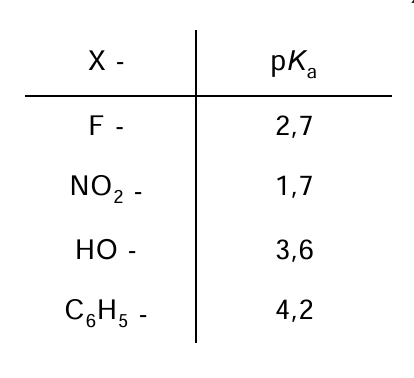
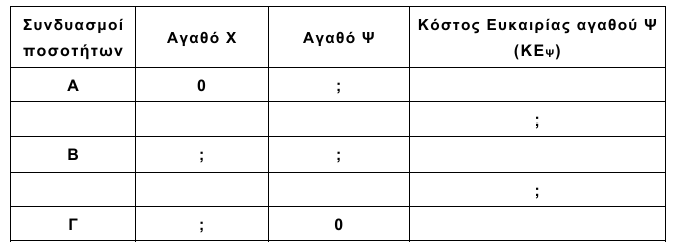
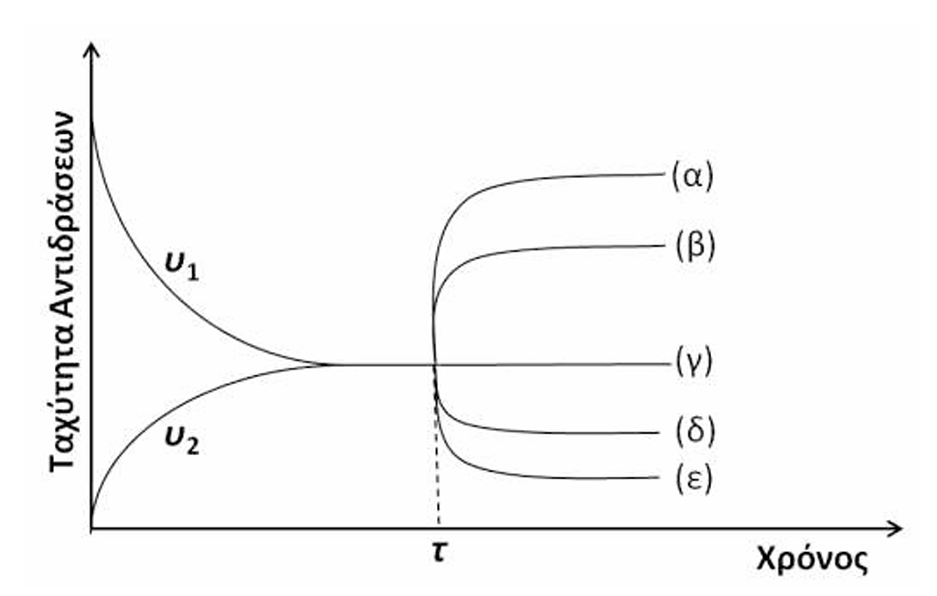

In [25]:
display_samples(df, n=3, prioritize_images=True)

4.1 Distribution by Subject and School Type

,Subject,Count
0,ancient_greek,222
1,latin,218
2,chemistry,204
3,physics,170
4,mathematics,147
5,biology,140
6,economics,133
7,computer_science,103
8,history,97
9,greek_language,90


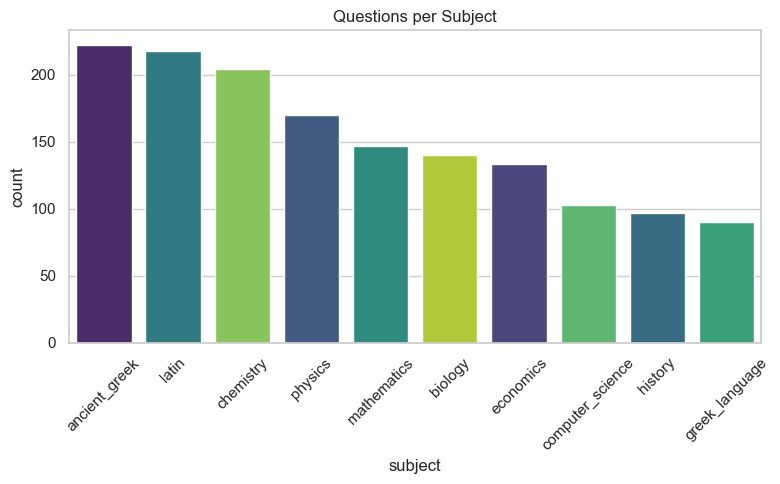

In [26]:
# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

,School Type,Count
0,GEL,1524


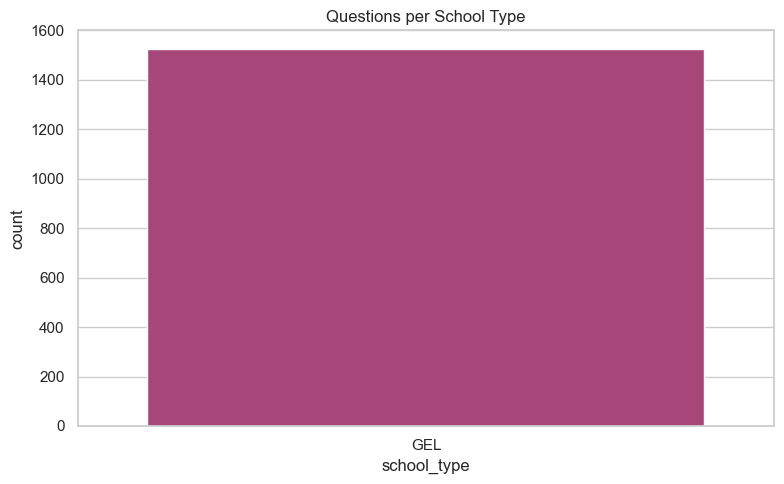

In [27]:
# School Type Distribution
fig_school, df_school = plot_school_type_dist(df)
display(df_school)
display(fig_school)

4.2 Distribution by Format and Reference Type

,Format,Count
0,open_ended,1017
1,true_false,270
2,multiple_choice,181
3,fill_in_the_gaps,40
4,matching,16


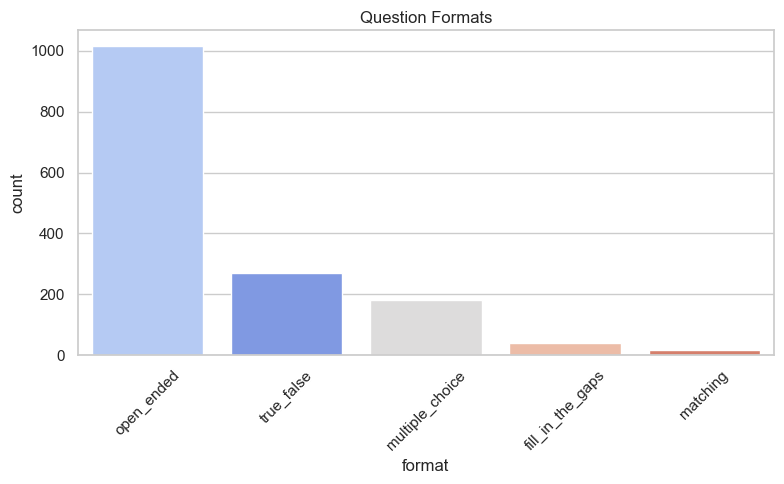

In [28]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

,Reference,Count
0,none,1040
1,passage,257
2,multimodal,226
3,table,1


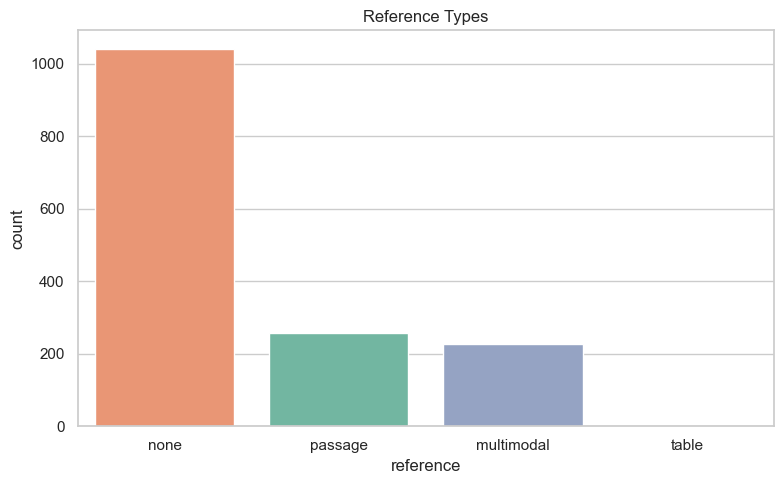

In [29]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

4.3 Temporal Trends

subject,ancient_greek,biology,chemistry,computer_science,economics,greek_language,history,latin,mathematics,physics
year,,,,,,,,,,
2020,33.0,22.0,34.0,16.0,17.0,16.0,14.0,40.0,21.0,24.0
2021,28.0,18.0,25.0,15.0,21.0,11.0,15.0,0.0,22.0,24.0
2022,22.0,22.0,23.0,15.0,20.0,11.0,14.0,33.0,21.0,24.0
2023,35.0,29.0,31.0,14.0,20.0,11.0,14.0,30.0,20.0,26.0
2024,42.0,27.0,33.0,17.0,19.0,11.0,13.0,33.0,22.0,26.0
2025,32.0,22.0,29.0,13.0,18.0,12.0,14.0,41.0,20.0,23.0
2026,30.0,0.0,29.0,13.0,18.0,18.0,13.0,41.0,21.0,23.0


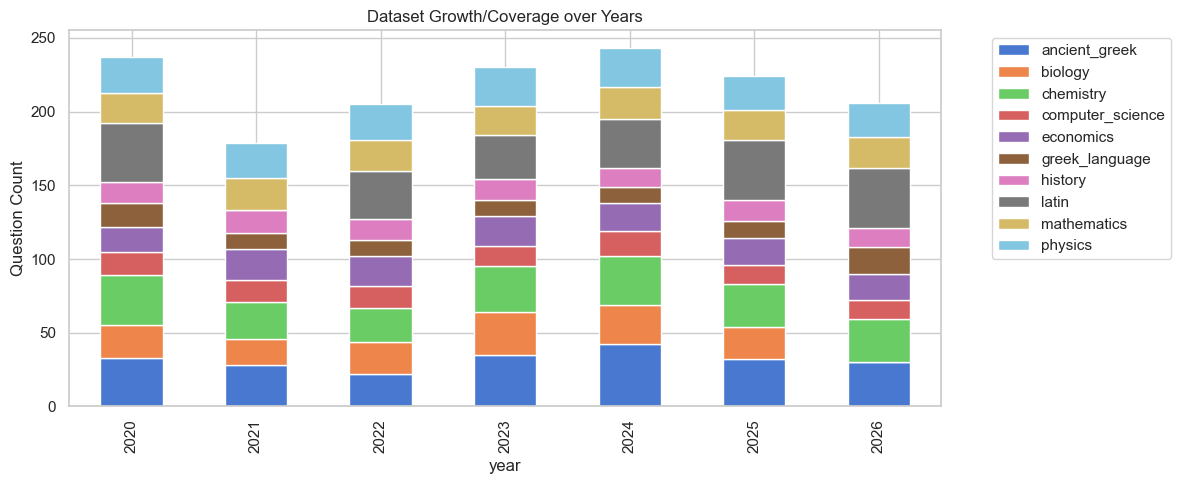

In [30]:
# Temporal Trends (Distribution over years per subject)
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

4.4 Point Values & Format Analysis

Percentage of questions with point values assigned:
100.00%


,count,mean,std,min,25%,50%,75%,max
points,1524.0,4.497047,4.193704,1.0,2.0,3.0,6.0,30.0


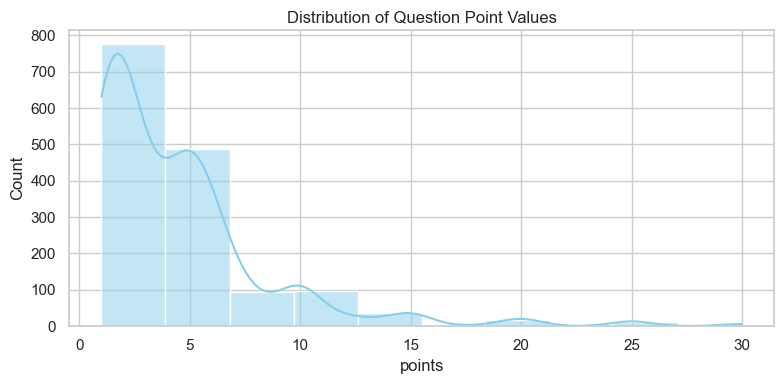

In [31]:
# Points Distribution
fig_points, df_points = plot_points_distribution(df)
display(df_points)
if fig_points is not None:
    display(fig_points)

,count,mean,std,min,25%,50%,75%,max
school_type,,,,,,,,
GEL,1524.0,4.497047,4.193704,1.0,2.0,3.0,6.0,30.0


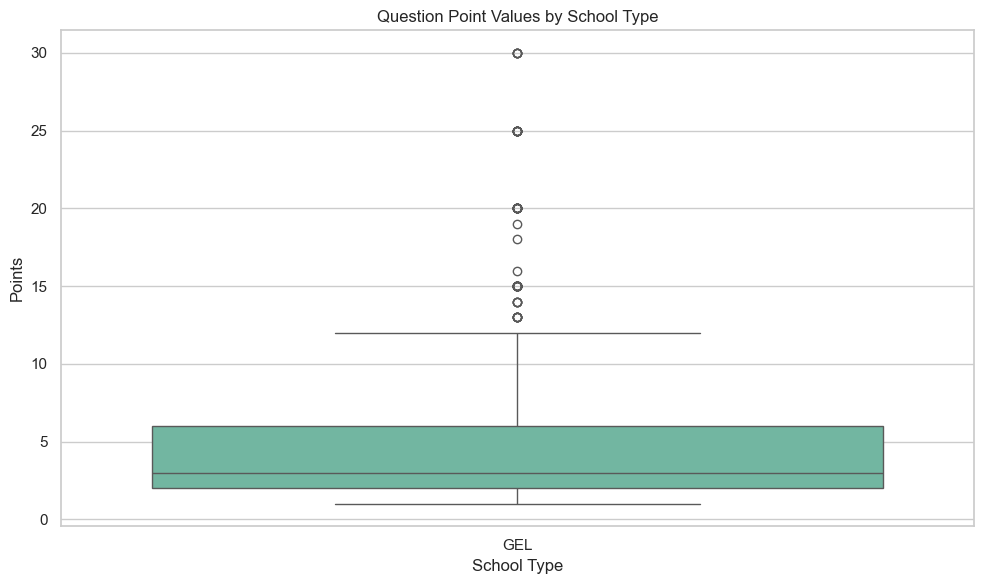

In [32]:
# Points by School Type 
fig_pts_school, df_pts_school = plot_points_by_school_type(df)
display(df_pts_school)
if fig_pts_school is not None:
    display(fig_pts_school)

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
ancient_greek,222.0,3.171171,3.706113,1.0,1.0,2.0,2.0,20.0
biology,140.0,4.400000,1.872943,1.0,3.0,5.0,5.0,10.0
chemistry,204.0,3.524510,2.023115,1.0,2.0,3.0,5.0,11.0
computer_science,103.0,6.786408,6.944670,2.0,2.0,5.0,8.0,25.0
economics,133.0,5.263158,3.320950,2.0,3.0,4.0,6.0,25.0
greek_language,90.0,7.833333,7.986294,1.0,2.0,3.0,15.0,30.0
history,97.0,7.082474,5.438424,2.0,2.0,5.0,12.0,25.0
latin,218.0,2.860092,3.437716,1.0,1.0,1.5,2.0,20.0
mathematics,147.0,4.761905,2.143270,1.0,2.0,5.0,6.0,10.0


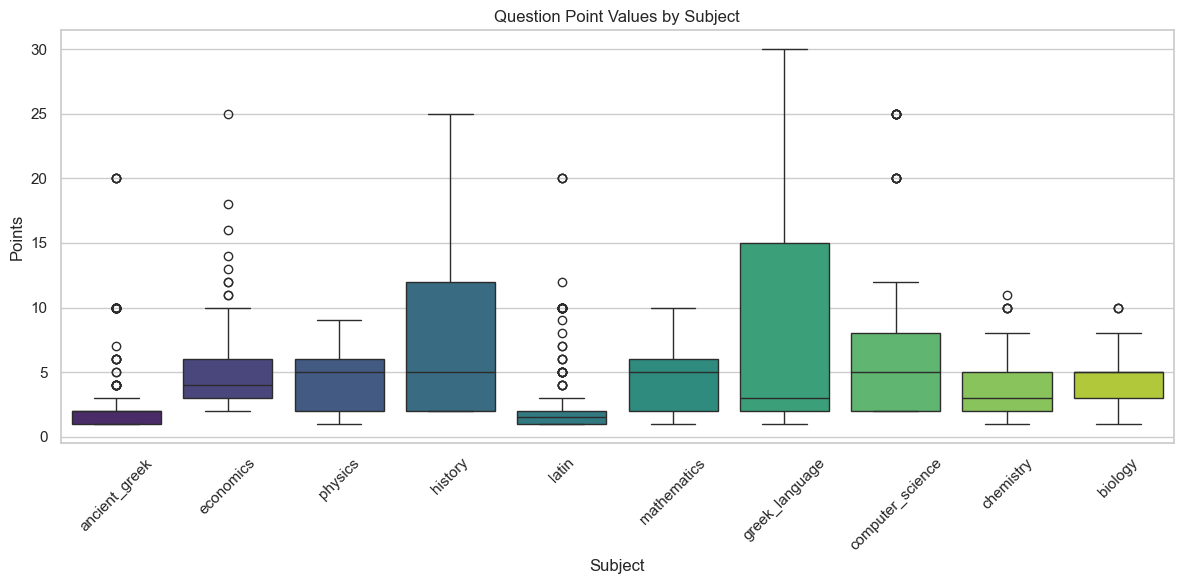

In [33]:
# Points by Subject
fig_pts_subj, df_pts_subj = plot_points_by_subject(df)
display(df_pts_subj)
if fig_pts_subj is not None:
    display(fig_pts_subj)

In [36]:
#additional snippet for chemistry
# 1. Φιλτράρουμε το dataset για να κρατήσουμε ΜΟΝΟ τα θέματα Χημείας
chemistry_df = df[df['subject'] == 'chemistry']

# 2. Ταξινομούμε τις ερωτήσεις με βάση τους πόντους (από το μεγαλύτερο στο μικρότερο)
# Η παράμετρος ascending=False σημαίνει φθίνουσα σειρά.
top_chem_questions = chemistry_df.sort_values(by='points', ascending=False)

# 3. Επιλέγουμε το όνομα της στήλης που έχει το κείμενο της ερώτησης
text_column = 'question' 

print("🏆 Τα outliers της Χημείας - Περιεχόμενο Ερωτήσεων:\n")
print("=" * 60)

# Παίρνουμε τις 3 πρώτες γραμμές και κάνουμε loop για να τις τυπώσουμε
for index, row in top_chem_questions.head(3).iterrows():
    print(f"📌 ID Ερώτησης: {row['id']}")
    print(f"📊 Μόρια: {row['points']} | Μορφή: {row['format']}")
    print(f"📖 Κείμενο Ερώτησης:\n")
    print(row[text_column])
    print("=" * 60)

🏆 Τα outliers της Χημείας - Περιεχόμενο Ερωτήσεων:

📌 ID Ερώτησης: chemistry_gel_2026_Γ1
📊 Μόρια: 11.0 | Μορφή: open_ended
📖 Κείμενο Ερώτησης:

Δίνεται το σχήμα χημικών μετατροπών της Εικόνας 3. Να γράψετε τους συντακτικούς τύπους των οργανικών ενώσεων $A, B, \Gamma, \Delta, E, \Theta, K, M, N, \Pi, P$. Δίνεται ότι η ένωση $A$ έχει μοριακό τύπο $C_\nu H_{2\nu}O_2$ και η οξείδωση της ένωσης $B$ οδηγεί αποκλειστικά στο αέριο $CO_2$.
📌 ID Ερώτησης: chemistry_gel_2025_Γ1
📊 Μόρια: 10.0 | Μορφή: open_ended
📖 Κείμενο Ερώτησης:

Δίνονται οι αντιδράσεις του παρακάτω σχήματος. Να γράψετε τους συντακτικούς τύπους των κύριων οργανικών ενώσεων $Α, Β, \Gamma, \Delta, Ε, Ζ, \Theta, Κ, \Lambda, Μ$.
📌 ID Ερώτησης: chemistry_gel_2023_Γ3
📊 Μόρια: 10.0 | Μορφή: open_ended
📖 Κείμενο Ερώτησης:

Σε τρία δοχεία περιέχονται τα παρακάτω μίγματα: 
1) Αιθανικό οξύ ($\ce{CH3COOH}$) και μεθανάλη ($\ce{HCHO}$) 
2) Μεθανικό οξύ ($\ce{HCOOH}$) και προπανόνη ($\ce{CH3COCH3}$) 
3) Αιθανόλη ($\ce{CH3CH2OH}$) και προπανάλ

format,fill_in_the_gaps,matching,multiple_choice,open_ended,true_false
subject,,,,,
ancient_greek,10,6,18,154,34
biology,0,4,37,99,0
chemistry,0,0,41,138,25
computer_science,8,2,0,58,35
economics,6,0,14,78,35
greek_language,0,0,10,55,25
history,0,0,0,62,35
latin,16,4,10,178,10
mathematics,0,0,0,111,36


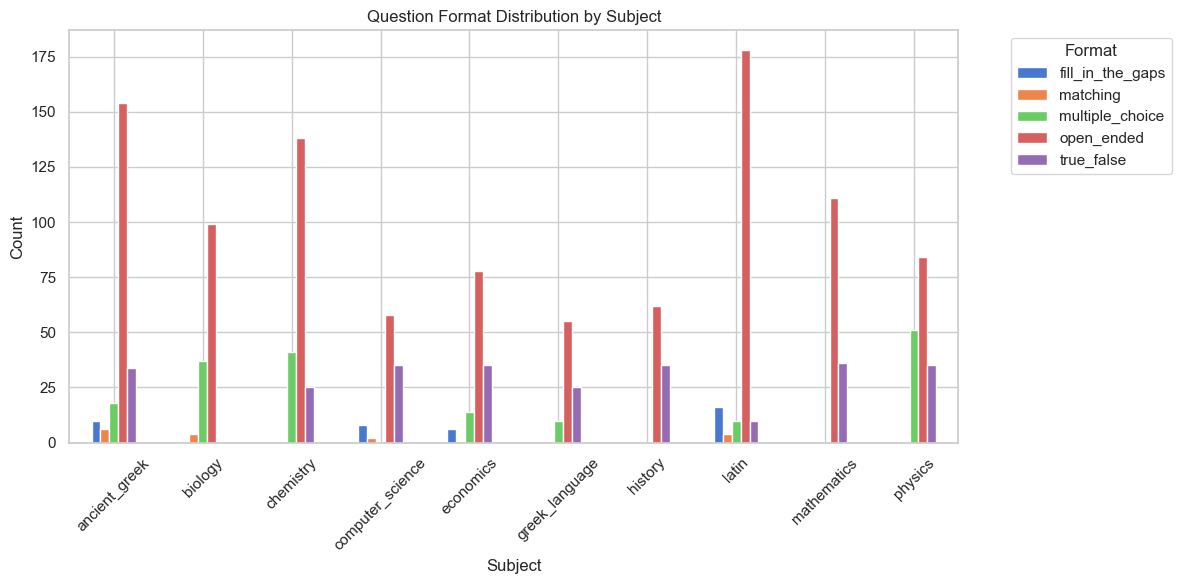

In [34]:
# Format by Subject
fig_fmt, df_fmt = plot_format_by_subject(df)
display(df_fmt)
display(fig_fmt)

4.5 Unique verification

In [ ]:
# 1. Μετατρέπουμε προσωρινά τις λίστες (choices) σε tuples για να μπορούν να συγκριθούν
if 'choices' in df.columns:
    choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
else:
    choices_hashable = None

# 2. Έλεγχος μοναδικότητας του 'id'
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")

# 3. Έλεγχος για ερωτήσεις με ολόιδιο περιεχόμενο (Question + Input)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns: subset_to_check.append('input')

if subset_to_check:
    content_duplicates = df.duplicated(subset=subset_to_check).sum()
    print(f"Rows with identical content (Question/Input): {content_duplicates}")
    
    # Αν βρει διπλότυπα, τα τυπώνει για να τα δεις
    if content_duplicates > 0:
        print("\nDisplaying samples of content duplicates:")
        dup_rows = df[df.duplicated(subset=subset_to_check, keep=False)]
        display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question']])

# 4. Έλεγχος για κενές τιμές (nulls) σε κρίσιμες στήλες
critical_cols = ['id', 'subject', 'school_type', 'question', 'format']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\n⚠️ Null values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

In [ ]:
# 1. Βρίσκει γραμμές που έχουν το κυριολεκτικό '\n' (ως κείμενο)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()

# 2. Βρίσκει γραμμές που είναι λίστες μετατρεπόμενες σε strings π.χ. "['a', 'b']"
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()

# 3. Βρίσκει τις "σωστές" απαντήσεις που έχουν πραγματικές αλλαγές γραμμής
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()

print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
if literal_nl_ids: print(f"IDs: {literal_nl_ids[:10]} ...\n")

print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
if json_list_ids: print(f"IDs: {json_list_ids[:10]} ...\n")

print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
if true_multiline_ids: print(f"IDs: {true_multiline_ids[:10]} ...")

In [ ]:
from IPython.display import Markdown

# Φορτώνουμε το dataset απευθείας από το Hugging Face
dataset = load_dataset(repo_id, split="train", token=token)

# Διάλεξε ένα δικό σου ID για τεστ
target_id = "ancient_greek_gel_2025_Α1.α.1" 

subset = dataset.filter(lambda x: x["id"] == target_id)

if len(subset) > 0:
    sample = subset[0]
    
    md_output = f"### ID: {sample['id']}\n"
    md_output += f"**Question:** {sample['question']}\n\n"
    
    if sample.get('input'):
        md_output += f"**Input:**\n{sample['input']}\n\n"
        
    if sample.get('images'):
        md_output += f"🖼️ **Images Attached:** {len(sample['images'])}\n\n"
        
    if sample.get('choices'):
        md_output += "#### Choices:\n"
        correct_idx = sample.get('answer_index')
        for i, choice in enumerate(sample['choices']):
            marker = "✅" if i == correct_idx else "⬜"
            md_output += f"- [{marker}] **{i}**: {choice}\n"
        md_output += f"\n**Correct Answer Index:** `{correct_idx}`"
    else:
        md_output += f"\n**Answer:**\n{sample['answer_text']}"
        
    display(Markdown(md_output))
else:
    print(f"ID {target_id} not found in Hugging Face dataset.")